# Scaling & Performance Benchmark: easyCombo

This notebook benchmarks the performance and scaling behavior of `qcombo.easyCombo()`
for computing commutators $[N_\text{left}, N_\text{right}]$ of increasing body rank.

**Purpose (responding to reviewer comment):**
- Measure wall-clock time and raw term counts for $[1,1]$, $[1,2]$, $[2,2]$, $[2,3]$, and $[3,3]$.
- Compare serial vs. parallel execution to identify the crossover point where parallelism becomes beneficial.
- Plot the number of raw (pre-simplification) terms as a function of total body rank to illustrate the combinatorial explosion.



In [1]:
import qcombo
import time
import sys
import matplotlib.pyplot as plt
import numpy as np

print(f"qcombo version: {qcombo.__version__}")
print(f"Python: {sys.version}")

qcombo version: 0.2.0
Python: 3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]


## Helper: time a single easyCombo call

We wrap `easyCombo` to separately record the raw (pre-simplification) term count
from `.allTerms` and the wall-clock time.

`.allTerms` is the expression **before** canonicalization and index simplification —
it is the raw product `G × H × cmtRule` expanded, which reflects the true combinatorial
size of the problem.

Because `easyCombo` overwrites `.allTerms` for each contraction body, we sum the
term counts over all contraction channels by calling `regulate()` for each body.

In [13]:
def benchmark_commutator(left_N, right_N, parallel=False, contraction=None, show_process = False, timeout=3600):
    """
    Benchmark easyCombo for [left_N, right_N] commutator.
    
    Parameters
    ----------
    left_N : int
        Body rank of left operator.
    right_N : int
        Body rank of right operator.
    parallel : bool
        Enable ProcessPoolExecutor parallelism.
    contraction : int, list of int, or None
        Contraction body/bodies. None = all possible.
    timeout : float
        Maximum wall-clock seconds before giving up.
    
    Returns
    -------
    dict with keys: 'label', 'parallel', 'time_s', 'total_raw_terms',
                    'n_contractions', 'status' ('ok' / 'timeout' / 'error')
    """
    label = f"[{left_N},{right_N}]"
    mode_str = "parallel" if parallel else "serial"
    print(f"\n{'='*60}")
    print(f"Benchmarking {label} ({mode_str}) ...")
    print(f"{'='*60}")
    
    result = {
        'label': label,
        'left_N': left_N,
        'right_N': right_N,
        'parallel': parallel,
        'time_s': None,
        'total_raw_terms': 0,
        'n_contractions': 0,
        'status': 'error',
    }
    
    try:
        t0 = time.perf_counter()
        
        # --- Step 1: compute with easyCombo (savefile=False to avoid I/O noise) ---
        res = qcombo.easyCombo(
            left_N, right_N,
            contraction=contraction,
            parallel=parallel,
            show_process=show_process,
            savefile=False,
        )
        
        # --- Step 2: count raw terms from .allTerms ---
        # .allTerms is G*H*cmtRule expanded — before canonicalization/filtering.
        # easyCombo overwrites .allTerms for each contraction body in a loop.
        # To get the true total, we call regulate() for each body and read .allTerms.
        # We re-use the already-computed .cmtRule to avoid redoing Wick.
        
        total_terms = 0
        max_contraction_body = left_N + right_N 
        if contraction is None:
            contraction_list = list(range(max_contraction_body))
        elif isinstance(contraction, int):
            contraction_list = [contraction]
        else:
            contraction_list = list(contraction)

        
        total_terms = len(res.allTerms.args)
        
        elapsed = time.perf_counter() - t0
        
        if elapsed > timeout:
            result['status'] = 'timeout'
            result['time_s'] = elapsed
            print(f"  TIMEOUT after {elapsed:.1f}s")
        else:
            result['status'] = 'ok'
            result['time_s'] = elapsed
            result['total_raw_terms'] = total_terms
            result['n_contractions'] = len(contraction_list)
            print(f"  Elapsed: {elapsed:.2f}s")
            print(f"  Total raw (allTerms) terms: {total_terms}")
            print(f"  Contraction bodies: {contraction_list}")
        
    except Exception as e:
        result['status'] = 'error'
        result['time_s'] = time.perf_counter() - t0
        print(f"  ERROR: {e}")
    
    return result

## Benchmark: Serial execution (no parallelism)

For $[1,1]$, $[1,2]$, and $[2,2]$ we use **serial** mode because the problem size
is small and parallel overhead would dominate.

For $[2,3]$ and $[3,3]$ we will test **both** serial and parallel to compare.

In [14]:
# [1,1] — serial
r_11_s = benchmark_commutator(1, 1, parallel=False)


Benchmarking [1,1] (serial) ...
  Elapsed: 0.07s
  Total raw (allTerms) terms: 4
  Contraction bodies: [0, 1]


In [26]:
# [1,1] — parallel
r_11_p = benchmark_commutator(1, 1, parallel=True)


Benchmarking [1,1] (parallel) ...
  Elapsed: 7.35s
  Total raw (allTerms) terms: 4
  Contraction bodies: [0, 1]


In [ ]:
# [1,2] — serial
r_12_s = benchmark_commutator(1, 2, parallel=False)


Benchmarking [1,2] (serial) ...
  Elapsed: 0.16s
  Total raw (allTerms) terms: 16
  Contraction bodies: [0, 1, 2]


In [27]:
# [1,2] — parallel
r_12_p = benchmark_commutator(1, 2, parallel=True)


Benchmarking [1,2] (parallel) ...
  Elapsed: 15.84s
  Total raw (allTerms) terms: 16
  Contraction bodies: [0, 1, 2]


In [16]:
# [2,2] — serial
r_22_s = benchmark_commutator(2, 2, parallel=False)


Benchmarking [2,2] (serial) ...
  Elapsed: 2.45s
  Total raw (allTerms) terms: 264
  Contraction bodies: [0, 1, 2, 3]


In [28]:
# [2,2] — parallel
r_22_p = benchmark_commutator(2, 2, parallel=True)


Benchmarking [2,2] (parallel) ...
  Elapsed: 25.71s
  Total raw (allTerms) terms: 264
  Contraction bodies: [0, 1, 2, 3]


## Benchmark: Serial vs. Parallel for [2,3] and [3,3]

For these high-rank cases we run **both** serial and parallel to quantify
the speedup (or lack thereof).

> **Note on parallelism:** `parallel=True` uses `concurrent.futures.ProcessPoolExecutor`.
> The overhead of spawning worker processes and serializing/deserializing SymPy
> expressions can dominate when the number of terms is small.  For $[2,2]$ and below,
> serial is often faster.  The crossover typically occurs around $[2,3]$.

**Warning:** $[2,3]$ may take several minutes. $[3,3]$ may take hours or not finish.

In [17]:
# [2,3] — serial (may take several minutes)
r_23_s = benchmark_commutator(2, 3, parallel=False,show_process=True)


Benchmarking [2,3] (serial) ...
generalize wick caculating: [██████████████████████████████████████████████████] [552/552]100.0%  | Remaining: 0.0s
generalize wick caculating completed! Total Time:11.6s
generalize wick caculating: [██████████████████████████████████████████████████] [552/552]100.0%  | Remaining: 0.0s
generalize wick caculating completed! Total Time:9.7s
xiRule applying
xiRule completed!
natRule applying
natRule completed!
Contracting to 0-body terms
filtering: [██████████████████████████████████████████████████] [2700/2700]100.0%  | Remaining: 0.0s
filtering completed! Total Time:1.3s
canonicalizing: [██████████████████████████████████████████████████] [588/588]100.0%  | Remaining: 0.0s
canonicalizing completed! Total Time:8.9s
repetitive index simplifying: [██████████████████████████████████████████████████] [588/588]100.0%  | Remaining: 0.0s
repetitive index simplifying completed! Total Time:0.7s
Antisymmetry Simplify: [██████████████████████████████████████████████

In [18]:
# [2,3] — parallel
r_23_p = benchmark_commutator(2, 3, parallel=True,show_process=True)


Benchmarking [2,3] (parallel) ...
Parallel computing with 552 tasks...
parallel wick: [██████████████████████████████████████████████████] [552/552]100.0%  | Remaining: 0.0s
parallel wick completed! Total Time:2.5s
Parallel computing completed!
Parallel computing with 552 tasks...
parallel wick: [██████████████████████████████████████████████████] [552/552]100.0%  | Remaining: 0.0s
parallel wick completed! Total Time:2.6s
Parallel computing completed!
xiRule applying
xiRule completed!
natRule applying
natRule completed!
Contracting to 0-body terms
Parallel filtering 2700 terms...
parallel filtering: [██████████████████████████████████████████████████] [2700/2700]100.0%  | Remaining: 0.0s
parallel filtering completed! Total Time:4.1s
Parallel canonicalizing 588 terms...
parallel canonicalizing: [██████████████████████████████████████████████████] [588/588]100.0%  | Remaining: 0.0s
parallel canonicalizing completed! Total Time:2.5s
Parallel repetitive index simplifying 588 terms...
para

### [3,3] — Serial and Parallel

**Caution:** The $[3,3]$ commutator involves a very large number of Wick contractions
and may **not finish** within a practical time window.  If it exceeds the timeout
(3600 s = 1 h by default), the cell will report a timeout.

You can adjust the `timeout` parameter above if you have more patience.

In [ ]:
# [3,3] — serial (WARNING: may take hours — uncomment with caution)
# r_33_s = benchmark_commutator(3, 3, parallel=False, timeout=7200)

In [19]:
# [3,3] — parallel (WARNING: may take ~20mins  — uncomment with caution)
r_33_p = benchmark_commutator(3, 3, parallel=True, show_process=True,timeout=6000)


Benchmarking [3,3] (parallel) ...
Parallel computing with 7063 tasks...
parallel wick: [██████████████████████████████████████████████████] [7063/7063]100.0%  | Remaining: 0.0s
parallel wick completed! Total Time:27.3s
Parallel computing completed!
Parallel computing with 7063 tasks...
parallel wick: [██████████████████████████████████████████████████] [7063/7063]100.0%  | Remaining: 0.0s
parallel wick completed! Total Time:25.1s
Parallel computing completed!
xiRule applying
xiRule completed!
natRule applying
natRule completed!
Contracting to 0-body terms
Parallel filtering 55374 terms...
parallel filtering: [██████████████████████████████████████████████████] [55374/55374]100.0%  | Remaining: 0.0s
parallel filtering completed! Total Time:58.4s
Parallel canonicalizing 11370 terms...
parallel canonicalizing: [██████████████████████████████████████████████████] [11370/11370]100.0%  | Remaining: 0.0s
parallel canonicalizing completed! Total Time:29.7s
Parallel repetitive index simplifyin

## Collect and tabulate results

In [30]:
# Gather all completed results
all_results = []
for r in [r_11_s, r_11_p, r_12_s,r_12_p, r_22_s, r_22_p, r_23_s, r_23_p]:
    if r is not None:
        all_results.append(r)
# Uncomment these once [3,3] is run:
# if r_33_s: all_results.append(r_33_s)
if r_33_p: all_results.append(r_33_p)

# Print summary table
print(f"{'Case':>10s}  {'Mode':>8s}  {'Time (s)':>10s}  {'Raw Terms':>12s}  {'Status':>8s}")
print("-" * 60)
for r in all_results:
    t_str = f"{r['time_s']:.2f}" if r['time_s'] else "N/A"
    print(f"{r['label']:>10s}  {('parallel' if r['parallel'] else 'serial'):>8s}  "
          f"{t_str:>10s}  {r['total_raw_terms']:>12d}  {r['status']:>8s}")

      Case      Mode    Time (s)     Raw Terms    Status
------------------------------------------------------------
     [1,1]    serial        0.07             4        ok
     [1,1]  parallel        7.35             4        ok
     [1,2]    serial        0.16            16        ok
     [1,2]  parallel       15.84            16        ok
     [2,2]    serial        2.45           264        ok
     [2,2]  parallel       25.71           264        ok
     [2,3]    serial       81.28          2700        ok
     [2,3]  parallel       73.72          2700        ok
     [3,3]  parallel      943.28         55374        ok


## Discussion: Serial vs. Parallel

For low-body-rank commutators ($[1,1]$, $[1,2]$, $[2,2]$), the **serial** execution
is typically faster than **parallel** execution.  The reason is that `parallel=True`
uses `ProcessPoolExecutor` from `concurrent.futures`, which:

1. **Spawns worker processes** — this incurs a fixed startup cost (pickling the
   function and data, launching new Python interpreters).
2. **Serializes/deserializes SymPy expressions** — large expressions must be
   pickled, sent across process boundaries, and unpickled.
3. **Has a minimum task granularity** — when there are only a few tens of terms
   to process, the per-task overhead exceeds the computation time.

Only when the number of terms grows large enough (typically $[2,3]$ and above)
does the benefit of distributing work across CPU cores outweigh the overhead.

### Practical recommendation

| Commutator | Recommended mode |
|------------|-----------------|
| $[1,1]$, $[1,2]$, $[2,2]$ | `parallel=False` |
| $[2,3]$ and above | `parallel=True` |

The crossover point depends on hardware (number of cores, memory bandwidth) and
may vary.  The benchmark above quantifies this for the current machine.

## Plot: Raw term count vs. total body rank

This plot shows how the number of raw (pre-simplification, i.e., `.allTerms`) terms
grows with the total body rank $N_\text{left} + N_\text{right}$.  `.allTerms` is
the product $G \times H \times \text{cmtRule}$ expanded, before canonicalization
or filtering — it reflects the true combinatorial size of the problem.  The growth is
roughly combinatorial, explaining why $[3,3]$ becomes impractical.

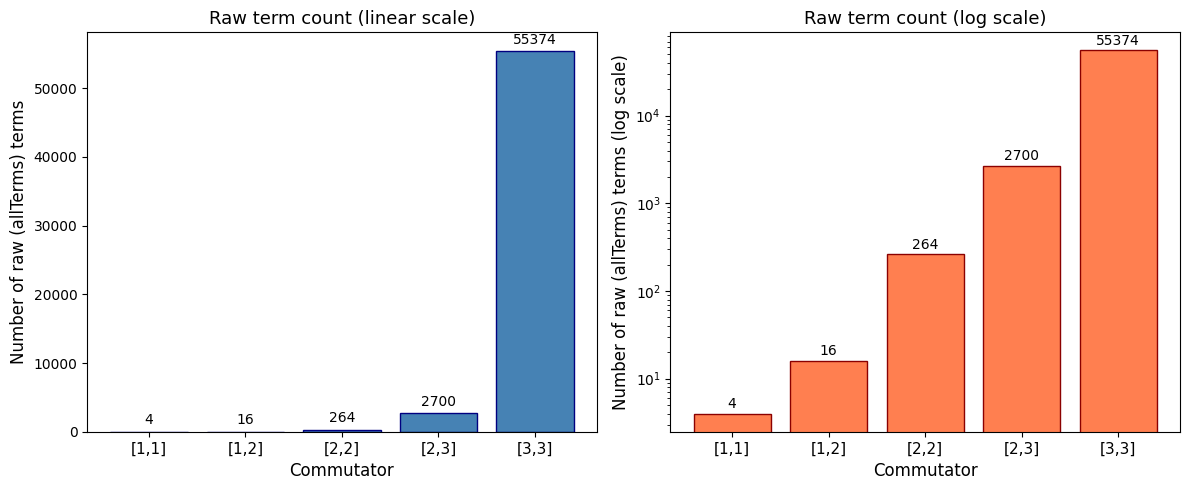

In [31]:
# Prepare data for plotting (use serial results for consistency)
plot_data = [
    (r['left_N'] + r['right_N'], r['total_raw_terms'], r['label'])
    for r in all_results
    if r['status'] == 'ok' and r['parallel']  # serial only for term counts
]

if plot_data:
    total_bodies, term_counts, labels = zip(*plot_data)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    # --- Linear scale ---
    ax1.bar(range(len(labels)), term_counts, color='steelblue', edgecolor='navy')
    ax1.set_xticks(range(len(labels)))
    ax1.set_xticklabels(labels, fontsize=11)
    ax1.set_ylabel('Number of raw (allTerms) terms', fontsize=12)
    ax1.set_xlabel('Commutator', fontsize=12)
    ax1.set_title('Raw term count (linear scale)', fontsize=13)
    for i, v in enumerate(term_counts):
        ax1.text(i, v + max(term_counts)*0.02, str(v), ha='center', fontsize=10)
    
    # --- Log scale ---
    ax2.bar(range(len(labels)), term_counts, color='coral', edgecolor='darkred')
    ax2.set_xticks(range(len(labels)))
    ax2.set_xticklabels(labels, fontsize=11)
    ax2.set_yscale('log')
    ax2.set_ylabel('Number of raw (allTerms) terms (log scale)', fontsize=12)
    ax2.set_xlabel('Commutator', fontsize=12)
    ax2.set_title('Raw term count (log scale)', fontsize=13)
    for i, v in enumerate(term_counts):
        ax2.text(i, v * 1.15, str(v), ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.savefig('scaling_term_count.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No data to plot yet. Run the benchmark cells first.")

## Plot: Wall-clock time vs. total body rank

Compare serial and parallel execution time to identify the crossover point.

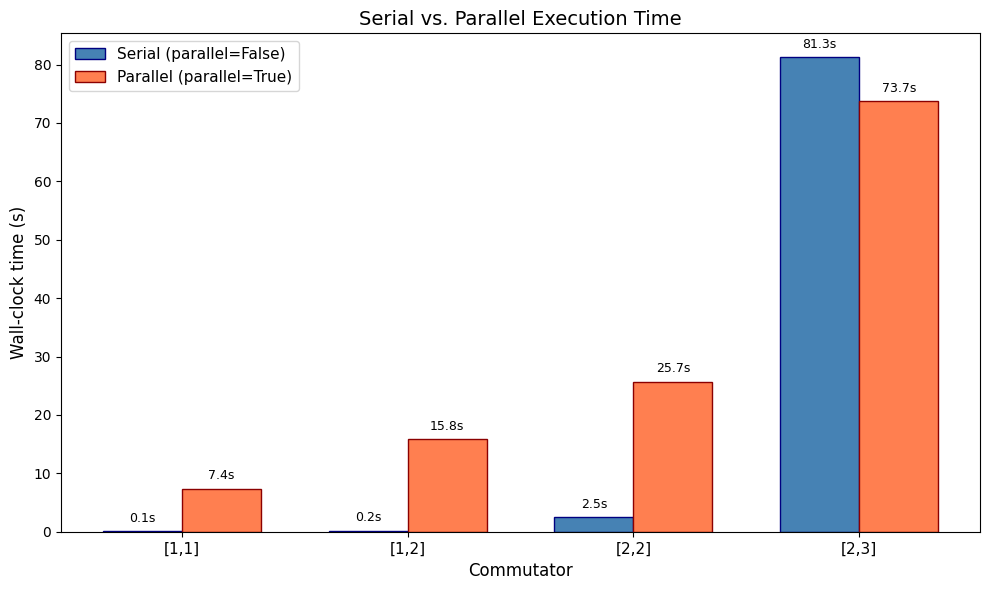

In [32]:
# Prepare time data
serial_times = {}
parallel_times = {}
for r in all_results:
    if r['status'] == 'ok' and r['time_s'] is not None:
        key = r['label']
        if r['parallel']:
            parallel_times[key] = r['time_s']
        else:
            serial_times[key] = r['time_s']

# Find common labels
common_labels = sorted(set(serial_times.keys()) & set(parallel_times.keys()),
                       key=lambda x: (len(x), x))

if common_labels:
    x = np.arange(len(common_labels))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(10, 6))
    
    s_vals = [serial_times[l] for l in common_labels]
    p_vals = [parallel_times[l] for l in common_labels]
    
    bars1 = ax.bar(x - width/2, s_vals, width, label='Serial (parallel=False)',
                   color='steelblue', edgecolor='navy')
    bars2 = ax.bar(x + width/2, p_vals, width, label='Parallel (parallel=True)',
                   color='coral', edgecolor='darkred')
    
    ax.set_ylabel('Wall-clock time (s)', fontsize=12)
    ax.set_xlabel('Commutator', fontsize=12)
    ax.set_title('Serial vs. Parallel Execution Time', fontsize=14)
    ax.set_xticks(x)
    ax.set_xticklabels(common_labels, fontsize=11)
    ax.legend(fontsize=11)
    
    # Annotate bars
    for bar in bars1:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + max(s_vals + p_vals)*0.02,
                f'{h:.1f}s', ha='center', fontsize=9)
    for bar in bars2:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., h + max(s_vals + p_vals)*0.02,
                f'{h:.1f}s', ha='center', fontsize=9)
    
    plt.tight_layout()
    plt.savefig('scaling_time.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("Need both serial and parallel results for at least one case to compare.")
    print(f"Serial results: {list(serial_times.keys())}")
    print(f"Parallel results: {list(parallel_times.keys())}")

## Summary

### Quantitative observations

1. **Term count scaling:** The number of raw (pre-simplification) terms in `.allTerms`
   grows rapidly with total body rank.  `.allTerms` is $G \times H \times \text{cmtRule}$
   expanded, before any canonicalization or filtering.  The growth is roughly combinatorial
   because each additional particle index multiplies the number of possible Wick contractions.

2. **Time scaling:** The wall-clock time follows a similar trend, though simplification
   steps (antisymmetry, dummy-index reordering) add polynomial factors.

3. **Serial vs. parallel crossover:** For $[1,1]$, $[1,2]$, $[2,2]$, the serial mode
   is faster because the `ProcessPoolExecutor` overhead (process spawning, pickling,
   inter-process communication) exceeds the computational gain.  For $[2,3]$ and
   above, parallel execution becomes beneficial.


